# Order estimation: Real Data

Calculate AIC and BIC on real data (all 4 markets). Let $K\in\{1, 2, 3, 4\}$

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from methods.data_utils import load_data, pre_avg, compute_returns, filter_day
from methods.hmm_utils import (
    fit_single_ar1, predict_single_ar1,
    fit_hmm_robust, fit_hmm_multiday,
    predict_hmm_mixture, get_filtered_probs,
    evaluate_predictions
)
from methods.plotting import set_style

set_style()


### Load and prepare data

Clip each weekday to 02:00–22:00 UTC, pre-average with k=10 ticks,
compute returns and scale to pips. Build segments list (one array per day).


In [5]:
K_TICKS    = 10
CLIP_START = "02:00"
CLIP_END   = "22:00"
MIN_OBS    = 100
TRAIN_FRAC = 0.8
markets    = ["EURUSD", "USDJPY", "USDZAR", "XAUUSD"]

market_segments = {}

for market in markets:
    df_raw   = load_data(market=market)
    all_days = sorted(set(df_raw.index.normalize().date))
    weekdays = [d for d in all_days if d.weekday() < 5]

    segs = []
    for day in weekdays:
        day_df = filter_day(df_raw, str(day))
        day_df = day_df.between_time(CLIP_START, CLIP_END)
        if len(day_df) < MIN_OBS:
            continue
        tmp = pre_avg(day_df, tick=True, k=K_TICKS)
        tmp = compute_returns(tmp)
        r = tmp["r"].values.astype(float) * 10_000
        if len(r) >= MIN_OBS:
            segs.append(r)

    market_segments[market] = segs
    print(f"{market}: {len(segs)} days, avg {np.mean([len(s) for s in segs]):.0f} obs/day")


EURUSD: 20 days, avg 5964 obs/day
USDJPY: 20 days, avg 8460 obs/day
USDZAR: 20 days, avg 14717 obs/day
XAUUSD: 20 days, avg 32686 obs/day


### Fit HMM-AR(1) for K ∈ {1, 2, 3, 4} — compute AIC and BIC

Fit on stitched series (Setup 2). Number of free parameters for a K-state HMM-AR(1):

- K AR coefficients (β), K noise standard deviations (σ)
- K(K−1) free entries of the transition matrix (each row sums to 1)
- Initial distribution fixed to uniform — not estimated

Total: k_K = 2K + K(K−1)


In [6]:
K_vals = [1, 2, 3, 4]

def n_params_hmm(K):
    return 2*K + K*(K - 1)

ic_records = []

for market, segs in market_segments.items():
    y_full  = np.concatenate(segs)
    split   = int(TRAIN_FRAC * len(y_full))
    y_train = y_full[:split]
    n       = len(y_train)

    for K in K_vals:
        print(f"{market} K={K} ...", end=" ")
        result, _ = fit_hmm_robust(y_train, K=K, n_starts=10, seed=42)
        loglik = -result.fun
        p      = n_params_hmm(K)
        ic_records.append({
            "market": market, "K": K,
            "loglik": round(loglik, 2),
            "n_params": p,
            "AIC": round(-2 * loglik + 2 * p, 2),
            "BIC": round(-2 * loglik + p * np.log(n), 2),
        })
        print("done")

ic_df = pd.DataFrame(ic_records)


EURUSD K=1 ... done
EURUSD K=2 ... done
EURUSD K=3 ... done
EURUSD K=4 ... done
USDJPY K=1 ... done
USDJPY K=2 ... done
USDJPY K=3 ... done
USDJPY K=4 ... done
USDZAR K=1 ... done
USDZAR K=2 ... done
USDZAR K=3 ... done
USDZAR K=4 ... done
XAUUSD K=1 ... done
XAUUSD K=2 ... done
XAUUSD K=3 ... done
XAUUSD K=4 ... done


### AIC and BIC tables


In [7]:
for ic in ["AIC", "BIC"]:
    print(ic)
    print(ic_df.pivot(index="K", columns="market", values=ic).round(1).to_string())
    print()


AIC
market    EURUSD     USDJPY     USDZAR      XAUUSD
K                                                 
1       115896.1  1522609.6  1676051.2  10510220.7
2       108663.6  1503928.1  1561076.8  10328735.3
3       106936.7  1498120.2  1544111.4  10301894.2
4       106341.6  1495151.0  1540298.0  10288169.3

BIC
market    EURUSD     USDJPY     USDZAR      XAUUSD
K                                                 
1       115915.0  1522629.2  1676072.0  10510243.0
2       108720.4  1503987.0  1561139.0  10328802.3
3       107050.3  1498238.0  1544235.8  10302028.2
4       106530.9  1495347.3  1540505.4  10288392.7



### Plot: AIC and BIC by K


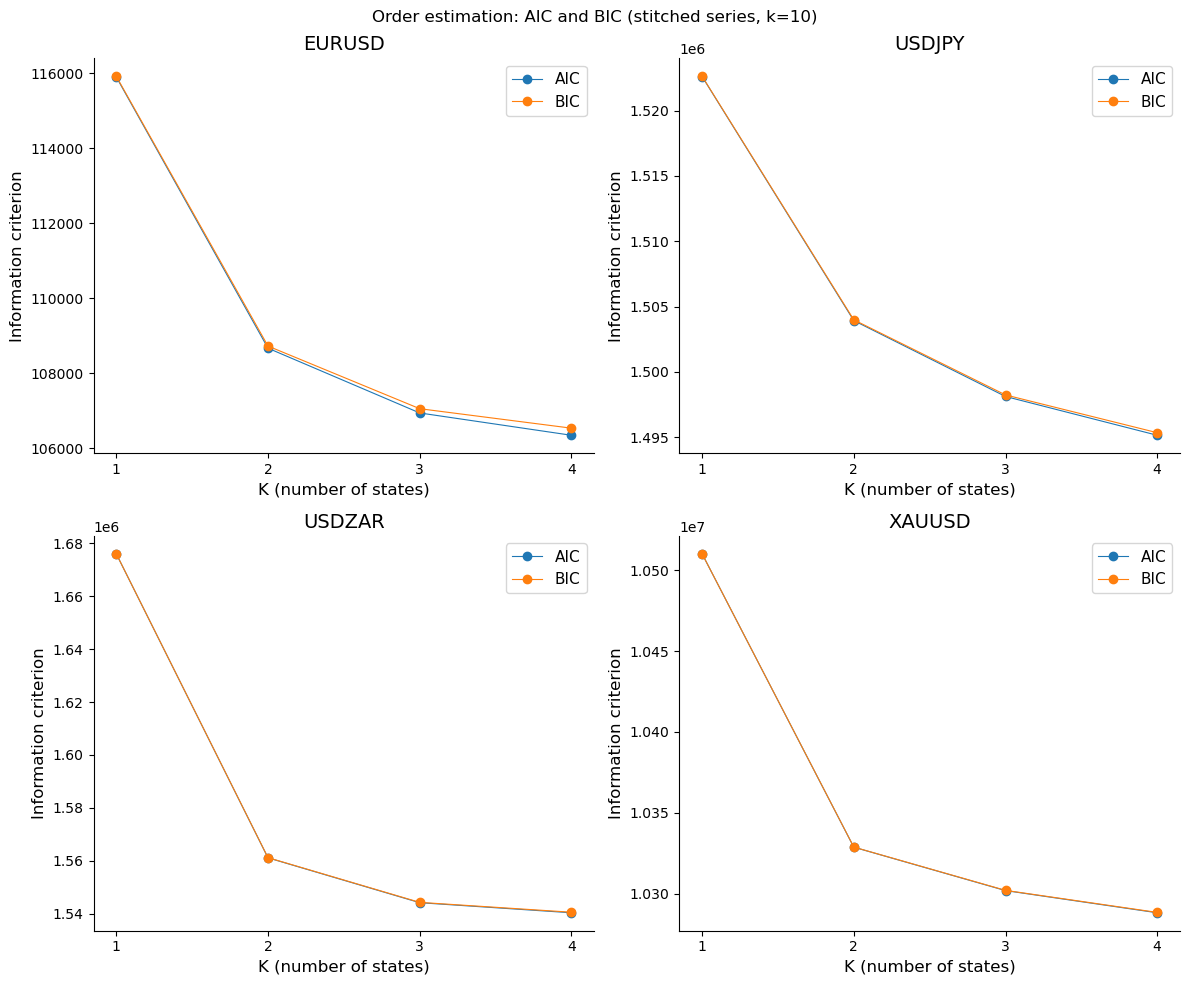

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, market in zip(axes.flat, markets):
    sub = ic_df[ic_df["market"] == market]
    ax.plot(sub["K"], sub["AIC"], marker="o", label="AIC")
    ax.plot(sub["K"], sub["BIC"], marker="o", label="BIC")
    ax.set_title(market)
    ax.set_xlabel("K (number of states)")
    ax.set_ylabel("Information criterion")
    ax.set_xticks(K_vals)
    ax.legend()

plt.suptitle("Order estimation: AIC and BIC (stitched series, k=10)")
plt.tight_layout()
plt.savefig("../plots/order_estimation_all_markets_1_to_4.pdf", bbox_inches="tight")
plt.show()


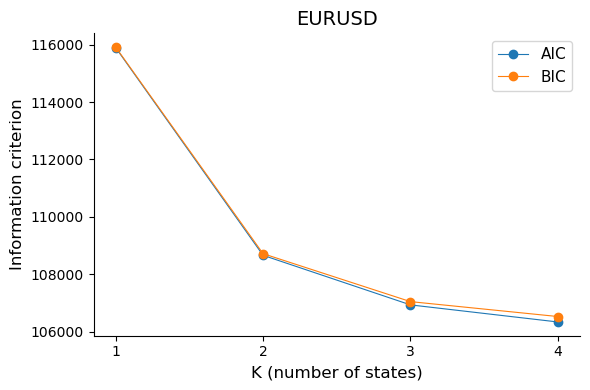

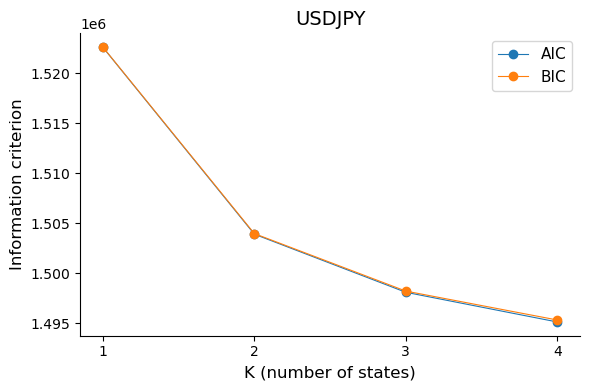

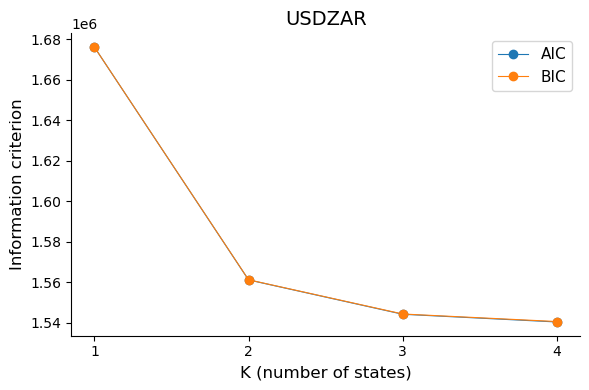

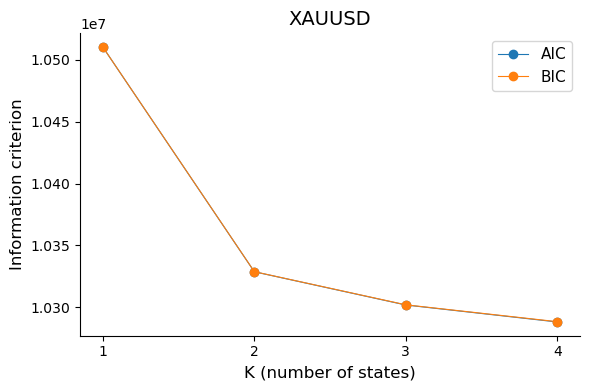

In [12]:
for market in markets:
    sub = ic_df[ic_df["market"] == market]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sub["K"], sub["AIC"], marker="o", label="AIC")
    ax.plot(sub["K"], sub["BIC"], marker="o", label="BIC")
    ax.set_title(market)
    ax.set_xlabel("K (number of states)")
    ax.set_ylabel("Information criterion")
    ax.set_xticks(K_vals)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"../plots/order_estimation_{market.lower()}.pdf", bbox_inches="tight")
    plt.show()
